# Molecular States and Drug Sensitivities Associated with Gene Expression Changes in Recurrent Glioblastoma

**Reference:** **Varn, F. S., Johnson, K. C., Martinek, J., Huse, J. T., Nasrallah, M. P., Wesseling, P., Cooper, L. A. D., Malta, T. M., Wade, T. E., Sabedot, T. S., Brat, D., Gould, P. V., Wöehrer, A., Aldape, K., Ismail, A., Sivajothi, S. K., Barthel, F. P., Kim, H., Kocakavuk, E., … GLASS Consortium. (2022). Glioma progression is shaped by genetic evolution and microenvironment interactions.** _Cell_, 185(12), **2184-2199.e16**. https://doi.org/10.1016/j.cell.2022.04.038
@articlevarnGliomaProgressionShaped2022

1. Load GLASS data
2. Get to know the dataset
3. Check raw gene expression data
4. Cleaning clinical data
5. Checking the relationship between patients and samples - `glass_all_samples.xlsx`
6. Create primer and first recurrent pairs
7. Check expression data availability of samples - `glass_primary_R1_pairs.xlsx`, `glass_primary_R1_pairs_all.xlsx`
8. Create the IDH-wildtype glioblastoma cohort - `glass_idhwt_gbm_primary_R1_pairs.xlsx`,
9. Export treatment variables - `glass_treatment_variables.xlsx`
10. Summary

In [1]:
import pandas as pd
from matplotlib_venn import venn3
import matplotlib.pyplot as plt

## 1. Loading GLASS
- **Source:** https://www.cbioportal.org/study/summary?id=difg_glass
    - https://datahub.assets.cbioportal.org/difg_glass.tar.gz
- **Raw Data:** `digf_glass.tar.tar`
- `difg_glass`
    - `README.md`
    - `LICENSE`
    - `data_clinical_patient.txt`
    - `data_clinical_sample.txt`
    - `data_cna.txt`
    - `data_cna_hg19.seg`
    - `data_mrna_seq_tpm.txt`
    - `data_mrna_seq_tpm_zscores_ref_all_samples.txt`
    - `data_mutations.txt`
    - `data_mutations_1.txt`
    - `data_mutations_2.txt`
    - `data_resource_definition.txt`
    - `data_resource_sample.txt`
    - `data_timeline_surgery.txt`
    - `data_timeline_treatment.txt`
    - `meta_clinical_patient.txt`
    - `meta_clinical_sample.txt`
    - `meta_cna.txt`
    - `meta_cna_hg19_seg.txt`
    - `meta_mrna_seq_tpm.txt`
    - `meta_mrna_seq_tpm_zscores_ref_all_samples.txt`
    - `meta_mutations.txt`
    - `meta_resource_definition.txt`
    - `meta_resource_sample.txt`
    - `meta_study.txt`
    - `meta_timeline_surgery.txt`
    - `meta_timeline_treatment.txt`
    - `case_lists`
        - `cases_all.txt`
        - `cases_cna.txt`
        - `cases_cnaseq.txt`
        - `cases_RNA_Seq_mRNA.txt`
        - `cases_sequenced.txt`

In [2]:
data_clinical_patient = pd.read_csv(
    "../raw_data/difg_glass/data_clinical_patient.txt",
    sep="\t",
    comment="#",
    low_memory=False
)

with open("../raw_data/difg_glass/data_clinical_patient.txt") as f:
    comments_p = [
        line[1:].rstrip("\n").split("\t")
        for line in f
        if line.startswith("#")
    ]

data_clinical_patient_comments = pd.DataFrame(comments_p[1:], columns=comments_p[0])

In [3]:
data_clinical_sample = pd.read_csv(
    "../raw_data/difg_glass/data_clinical_sample.txt",
    sep="\t",
    comment="#",
    low_memory=False
)

with open("../raw_data/difg_glass/data_clinical_sample.txt") as f:
    comments_s = [
        line[1:].rstrip("\n").split("\t")
        for line in f
        if line.startswith("#")
    ]

data_clinical_sample_comments = pd.DataFrame(comments_s[1:], columns=comments_s[0])

In [4]:
data_cna = pd.read_csv(
    "../raw_data/difg_glass/data_cna.txt",
    sep="\t",
    comment="#",
    low_memory=False
)

In [5]:
data_cna_hg19 = pd.read_csv(
    "../raw_data/difg_glass/data_cna_hg19.seg",
    sep="\t",
    comment="#",
    low_memory=False
)

In [6]:
data_mrna_seq_tpm = pd.read_csv(
    "../raw_data/difg_glass/data_mrna_seq_tpm.txt",
    sep="\t",
    comment="#",
    index_col=0,
    low_memory=False
)

In [7]:
data_mrna_seq_tpm_zscores_ref_all_samples = pd.read_csv(
    "../raw_data/difg_glass/data_mrna_seq_tpm_zscores_ref_all_samples.txt",
    sep="\t",
    comment="#",
    index_col=0,
    low_memory=False
)

In [8]:
data_mutations = pd.read_csv(
    "../raw_data/difg_glass/data_mutations.txt",
    sep="\t",
    comment="#",
    low_memory=False
)

In [9]:
data_mutations_1 = pd.read_csv(
    "../raw_data/difg_glass/data_mutations_1.txt",
    sep="\t",
    comment="#",
    low_memory=False
)

In [10]:
data_mutations_2 = pd.read_csv(
    "../raw_data/difg_glass/data_mutations_2.txt",
    sep="\t",
    comment="#",
    low_memory=False
)

In [11]:
data_resource_definition = pd.read_csv(
    "../raw_data/difg_glass/data_resource_definition.txt",
    sep="\t",
    comment="#",
    low_memory=False
)

In [12]:
data_resource_definition

,RESOURCE_ID,DISPLAY_NAME,RESOURCE_TYPE,DESCRIPTION,OPEN_BY_DEFAULT,PRIORITY
0,HE,H&E Slide,SAMPLE,H&E Slide,True,1


In [13]:
data_resource_sample = pd.read_csv(
    "../raw_data/difg_glass/data_resource_sample.txt",
    sep="\t",
    comment="#",
    low_memory=False
)

In [14]:
data_timeline_surgery = pd.read_csv(
    "../raw_data/difg_glass/data_timeline_surgery.txt",
    sep="\t",
    comment="#",
    low_memory=False
)

In [15]:
data_timeline_treatment = pd.read_csv(
    "../raw_data/difg_glass/data_timeline_treatment.txt",
    sep="\t",
    comment="#",
    low_memory=False
)

In [16]:
meta_clinical_patient = pd.read_csv(
    "../raw_data/difg_glass/meta_clinical_patient.txt",
    sep="\t",
    low_memory=False
)

In [17]:
meta_clinical_sample = pd.read_csv(
    "../raw_data/difg_glass/meta_clinical_sample.txt",
    sep="\t",
    low_memory=False
)

In [18]:
meta_cna = pd.read_csv(
    "../raw_data/difg_glass/meta_cna.txt",
    sep="\t",
    low_memory=False
)

In [19]:
meta_cna_hg19_seg = pd.read_csv(
    "../raw_data/difg_glass/meta_cna_hg19_seg.txt",
    sep="\t",
    low_memory=False
)

In [20]:
meta_mrna_seq_tpm = pd.read_csv(
    "../raw_data/difg_glass/meta_mrna_seq_tpm.txt",
    sep="\t",
    low_memory=False
)

In [21]:
meta_mrna_seq_tpm_zscores_ref_all_samples = pd.read_csv(
    "../raw_data/difg_glass/meta_mrna_seq_tpm_zscores_ref_all_samples.txt",
    sep="\t",
    low_memory=False
)

In [22]:
meta_mutations = pd.read_csv(
    "../raw_data/difg_glass/meta_mutations.txt",
    sep="\t",
    low_memory=False
)

In [23]:
meta_resource_definition = pd.read_csv(
    "../raw_data/difg_glass/meta_resource_definition.txt",
    sep="\t",
    low_memory=False
)

In [24]:
meta_resource_sample = pd.read_csv(
    "../raw_data/difg_glass/meta_resource_sample.txt",
    sep="\t",
    low_memory=False
)

In [25]:
meta_study = pd.read_csv(
    "../raw_data/difg_glass/meta_study.txt",
    sep="\t",
    low_memory=False
)

In [26]:
meta_timeline_surgery = pd.read_csv(
    "../raw_data/difg_glass/meta_timeline_surgery.txt",
    sep="\t",
    low_memory=False
)

In [27]:
meta_timeline_treatment = pd.read_csv(
    "../raw_data/difg_glass/meta_timeline_treatment.txt",
    sep="\t",
    low_memory=False
)

In [28]:
cases_all = pd.read_csv(
    "../raw_data/difg_glass/case_lists/cases_all.txt",
    low_memory=False
)

In [29]:
cases_cna = pd.read_csv(
    "../raw_data/difg_glass/case_lists/cases_cna.txt",
    low_memory=False
)

In [30]:
cases_cnaseq = pd.read_csv(
    "../raw_data/difg_glass/case_lists/cases_cnaseq.txt",
    low_memory=False
)

In [31]:
cases_RNA_Seq_mRNA = pd.read_csv(
    "../raw_data/difg_glass/case_lists/cases_RNA_Seq_mRNA.txt",
    low_memory=False
)

In [32]:
cases_sequenced = pd.read_csv(
    "../raw_data/difg_glass/case_lists/cases_sequenced.txt",
    low_memory=False
)

## 2. Get to know database
- `data_*` are data
- `meta_*` are metadata
- `cases_*` number of cases for which the condition is true
- `README.md` contains the resources and pipelines used to compile this dataset

In [33]:
meta_clinical_patient

,cancer_study_identifier: difg_glass
0,genetic_alteration_type: CLINICAL
1,datatype: PATIENT_ATTRIBUTES
2,data_filename: data_clinical_patient.txt


In [34]:
data_clinical_patient_comments

,Patient Identifier,Project ID,Sex,Age,Overall Survival,Overall Survival (months),Tissue Source
0,Unique patient identifier,Indicates whether the data was collected for t...,Sex,Patient's age at first diagnosis,Overall patient survival status,Overall survival in months since first diagnos...,Tissue source site for each subject
1,STRING,STRING,STRING,NUMBER,STRING,NUMBER,STRING
2,1,1,1,1,1,1,1


In [35]:
cols = ["PATIENT_ID",
        "CASE_PROJECT",
        "SEX",
        "AGE",
        "OS_STATUS",
        "TISSUE_SOURCE"]

num_cols = data_clinical_patient.columns[~data_clinical_patient.columns.isin(cols)]

data_clinical_patient[cols] = data_clinical_patient[cols].astype("string")

for col in num_cols:
    data_clinical_patient[col] = pd.to_numeric(
        data_clinical_patient[col],
        errors="coerce"
    )

In [36]:
data_clinical_patient.head()

,PATIENT_ID,CASE_PROJECT,SEX,AGE,OS_STATUS,OS_MONTHS,TISSUE_SOURCE
0,GLSS-19-0266,GLSS,Male,71.0,1:DECEASED,35.0,Case Western Reserve University
1,GLSS-19-0267,GLSS,Male,61.0,1:DECEASED,14.0,Case Western Reserve University
2,GLSS-19-0268,GLSS,Male,64.0,1:DECEASED,12.0,Case Western Reserve University
3,GLSS-19-0269,GLSS,Male,57.0,1:DECEASED,16.0,Case Western Reserve University
4,GLSS-19-0271,GLSS,Male,56.0,1:DECEASED,14.0,Case Western Reserve University


- `data_clinical_patient.txt` - Clinical patient attributes
    - `PATIENT_ID`
        - Unique patient identifier
    - `CASE_PROJECT`
        - Indicates whether the data was collected for the purpose of GLASS or TCGA
    - `SEX`
        - Sex
    - `AGE`
        - Patient's age at first diagnosis
    - `OS_STATUS`
        - Overall patient survival status
    - `OS_MONTHS`
        - Overall survival in months since first diagnosis to last known follow-up
    - `TISSUE_SOURCE`
        - Tissue source site for each subject

In [37]:
meta_clinical_sample

,cancer_study_identifier: difg_glass
0,genetic_alteration_type: CLINICAL
1,datatype: SAMPLE_ATTRIBUTES
2,data_filename: data_clinical_sample.txt


In [38]:
data_clinical_sample_comments

,Patient Identifier,Sample Identifier,Sample Type,Oncotree Code,Histology,Tumor Grade,IDH Status,IDH and Codeletion Status,Tumor Classification,Codeletion Status,...,MGMT Methylation Method,DNA Aliquot Barcode,RNA Aliquot Barcode,Analysis Type,Stromal Score,Immune Score,ESTIMATE Score,Purity,Cancer Type,Cancer Type Detailed
0,Unique patient identifier,Unique sample identifier,Sample Type,Oncotree code,Histology classification,Pathological tumor grade,Canonical mutation in IDH gene,Combination of the idh_status and codel_status...,Tumor classification according to WHO,Codeletion status of chromosomal arms 1p and 19q,...,MGMT methylation method,"A variable that stitches subject, sample type,...","A variable that stitches subject, sample type,...",Variable representing either whole genome sequ...,An ssGSEA-based enrichment score calculated fr...,An ssGSEA-based enrichment score calculated fr...,The ESTIMATE score that is calculated using bo...,The estimated tumor purity value calculated fr...,Cancer Type,Cancer Type Detailed
1,STRING,STRING,STRING,STRING,STRING,STRING,STRING,STRING,STRING,STRING,...,STRING,STRING,STRING,STRING,NUMBER,NUMBER,NUMBER,NUMBER,STRING,STRING
2,1,1,1,1,1,1,1,1,1,1,...,1,0,0,1,0,0,0,0,1,1


In [39]:
cases_all

,cancer_study_identifier: difg_glass
0,stable_id: difg_glass_all
1,case_list_name: All samples
2,case_list_description: All samples (693 samples)
3,case_list_category: all_cases_in_study
4,case_list_ids: \tGLSS-19-0266-R1\tGLSS-19-0266...


In [40]:
cols = ["PATIENT_ID",
        "SAMPLE_ID",
        "SAMPLE_TYPE",
        "ONCOTREE_CODE",
        "HISTOLOGY",
        "TUMOR_GRADE",
        "IDH_STATUS",
        "IDH_CODEL_STATUS",
        "TUMOR_CLASSIFICATION",
        "CODEL_STATUS",
        "MGMT_METHYLATION",
        "SURGERY_TYPE",
        "SURGERY_INDICATION",
        "SURGERY_EXTENT_OF_RESECTION",
        "SURGERY_LATERALITY",
        "SURGERY_LOCATION",
        "TREATMENT_TMZ",
        "TREATMENT_TMZ_CYCLES_6",
        "TREATMENT_CONCURRENT_TMZ",
        "TREATMENT_RADIOTHERAPY",
        "ALKYLATING_AGENT_TX",
        "MGMT_METHYLATION_METHOD",
        "DNA_ALIQUOT_BARCODE",
        "RNA_ALIQUOT_BARCODE",
        "ALIQUOT_ANALYSIS_TYPE",
        "CANCER_TYPE",
        "CANCER_TYPE_DETAILED"]

num_cols = data_clinical_sample.columns[~data_clinical_sample.columns.isin(cols)]

data_clinical_sample[cols] = data_clinical_sample[cols].astype("string")

for col in num_cols:
    data_clinical_sample[col] = pd.to_numeric(
        data_clinical_sample[col],
        errors="coerce"
    )

In [41]:
data_clinical_sample.head()

,PATIENT_ID,SAMPLE_ID,SAMPLE_TYPE,ONCOTREE_CODE,HISTOLOGY,TUMOR_GRADE,IDH_STATUS,IDH_CODEL_STATUS,TUMOR_CLASSIFICATION,CODEL_STATUS,...,MGMT_METHYLATION_METHOD,DNA_ALIQUOT_BARCODE,RNA_ALIQUOT_BARCODE,ALIQUOT_ANALYSIS_TYPE,STROMAL_SCORE,IMMUNE_SCORE,ESTIMATE_SCORE,PURITY,CANCER_TYPE,CANCER_TYPE_DETAILED
0,GLSS-19-0266,GLSS-19-0266-R1,First Recurrence,GB,Glioblastoma,IV,IDHwt,IDHwt,"Glioblastoma, IDH-wildtype",<NA>,...,<NA>,GLSS-19-0266-R1-01D-WXS-0AUVTN,<NA>,WXS,NaN,NaN,NaN,NaN,Glioma,Glioblastoma
1,GLSS-19-0266,GLSS-19-0266-TP,Tumor Primary,GB,Glioblastoma,IV,IDHwt,IDHwt,"Glioblastoma, IDH-wildtype",<NA>,...,Array,GLSS-19-0266-TP-01D-WXS-F78XXN,<NA>,WXS,NaN,NaN,NaN,NaN,Glioma,Glioblastoma
2,GLSS-19-0267,GLSS-19-0267-R1,First Recurrence,GB,Glioblastoma,IV,<NA>,IDHwt,"Glioblastoma, NOS",<NA>,...,<NA>,GLSS-19-0267-R1-01D-WXS-2AVAZ0,GLSS-19-0267-R1-01R-RNA-NCCNA9,"WXS, RNA",-741.873952,-748.253426,-1490.127378,0.926327,Glioma,Glioblastoma
3,GLSS-19-0267,GLSS-19-0267-TP,Tumor Primary,GB,Glioblastoma,IV,<NA>,IDHwt,"Glioblastoma, NOS",<NA>,...,Array,GLSS-19-0267-TP-01D-WXS-CS4K8X,GLSS-19-0267-TP-01R-RNA-UETVPC,"WXS, RNA",-459.366877,5.800561,-453.566316,0.858526,Glioma,Glioblastoma
4,GLSS-19-0268,GLSS-19-0268-R1,First Recurrence,GB,Glioblastoma,IV,<NA>,IDHwt,"Glioblastoma, NOS",<NA>,...,<NA>,GLSS-19-0268-R1-01D-WXS-KDBRYM,GLSS-19-0268-R1-01R-RNA-A1U9K5,"WXS, RNA",-350.465476,644.321629,293.856153,0.797219,Glioma,Glioblastoma


- All unique samples in study: 693
- `data_clinical_sample.txt` - Clinical sample attributes
    - `PATIENT_ID`
        - Unique patient identifier
    - `SAMPLE_ID`
        - Unique sample identifier
    - `SAMPLE_TYPE`
        - Sample Type
    - `ONCOTREE_CODE`
        - Oncotree code
    - `HISTOLOGY`
        - Histology classification
    -  `TUMOR_GRADE`
        - Pathological tumor grade
    -  `IDH_STATUS`
        - IDH Status
    -  `IDH_CODEL_STATUS`
        - IDH and Codeletion Status
        - Combination of the idh_status and codel_status variables
    - `TUMOR_CLASSIFICATION`
        - Tumor classification according to WHO
    -  `CODEL_STATUS`
        - Codeletion status of chromosomal arms 1p and 19q
    -  `MGMT_METHYLATION`
        - Clinical assessment of MGMT methylation in samples
    - `SURGERY_TYPE`
        - Surgery type
    -  `SURGERY_INDICATION`
        - Surgery indication
    - `SURGERY_EXTENT_OF_RESECTION`
        - Indicated extent of resection needed for sample collection
    - `SURGERY_LATERALITY`
        - Hemisphere from which the tumor was resected
    - `SURGERY_LOCATION`
        - Brain region from which tumor was resected
    - `TREATMENT_TMZ`
        - Indicates whether a subject received temozolomide (tmz) for each surgical sample
    - `TREATMENT_TMZ_CYCLES`
        - Number of temozolomide treatment cycles
    -  `TREATMENT_TMZ_CYCLES_6`
        - Indicates whether a subject received at least six cycles of temozolomide
    -  `TREATMENT_CONCURRENT_TMZ`
        - Indicate whether temozolomide was administered concurrently with radiotherapy
    -  `TREATMENT_RADIOTHERAPY`
        - Indicates whether a subject received radiotherapy
    -  `TREATMENT_RADIATION_DOSE_GY`
        - Radiation Dose (Gy)
    - `ALKYLATING_AGENT_TX`
        - Treatment with alkylating agents
    - `MGMT_METHYLATION_METHOD`
        - MGMT methylation method
    - `DNA_ALIQUOT_BARCODE`
        - A variable that stitches subject, sample type, portion, sequencing type, and a unique identifier together
    - `RNA_ALIQUOT_BARCODE`
        - A variable that stitches subject, sample type, portion, sequencing type, and a unique identifier together
    - `ALIQUOT_ANALYSIS_TYPE`
        - Variable representing either whole genome sequencing (WGS) or whole exome sequencing (WXS)
    - `STROMAL_SCORE`
        - An ssGSEA-based enrichment score calculated from the ESTIMATE stromal signature. Represents stromal content in a given tumor.
    - `IMMUNE_SCORE`
        - An ssGSEA-based enrichment score calculated from the ESTIMATE immune signature. Represents general immune content in a given tumor.
    - `ESTIMATE_SCORE`
        - The ESTIMATE score that is calculated using both the stromal and immune score that represents non-tumor content in a tumor.
    - `PURITY`
        - The estimated tumor purity value calculated from the estimate_score.
    - `CANCER_TYPE`
        - Cancer Type
    - `CANCER_TYPE_DETAILED`
        - Cancer Type Detailed

In [42]:
meta_cna

,cancer_study_identifier: difg_glass
0,genetic_alteration_type: COPY_NUMBER_ALTERATION
1,stable_id: cna
2,show_profile_in_analysis_tab: true
3,profile_name: Copy Number Alterations
4,profile_description: Copy number alterations b...
5,datatype: DISCRETE
6,data_filename: data_cna.txt


In [43]:
cases_cna

,cancer_study_identifier: difg_glass
0,stable_id: difg_glass_cna
1,case_list_name: Samples with CNA data
2,case_list_description: Samples with CNA data (...
3,case_list_category: all_cases_with_cna_data
4,case_list_ids: \tGLSS-19-0266-R1\tGLSS-19-0266...


In [44]:
data_cna.iloc[:5, :5]

,Hugo_Symbol,GLSS-19-0266-R1,GLSS-19-0266-TP,GLSS-19-0267-R1,GLSS-19-0267-TP
0,A1BG,0.0,1.0,0.0,0.0
1,A1BG-AS1,0.0,1.0,0.0,0.0
2,A1CF,2.0,0.0,2.0,-1.0
3,A2M,0.0,0.0,0.0,0.0
4,A2M-AS1,0.0,0.0,0.0,0.0


- Samples with CNA data: 629 samples (`cases_cna.txt`)
- `data_cna.txt`
    - Copy number alterations based on GATK segmentation output.

In [45]:
meta_cna_hg19_seg

,cancer_study_identifier: difg_glass
0,genetic_alteration_type: COPY_NUMBER_ALTERATION
1,datatype: SEG
2,reference_genome_id: hg19
3,description: Segment data values
4,data_filename: data_cna_hg19.seg


In [46]:
cases_cnaseq

,cancer_study_identifier: difg_glass
0,stable_id: difg_glass_cnaseq
1,case_list_name: Samples with mutation and CNA ...
2,case_list_description: Samples with mutation a...
3,case_list_category: all_cases_with_mutation_an...
4,case_list_ids: GLSS-19-0266-R1\tGLSS-19-0266-T...


In [47]:
data_cna_hg19.head()

,ID,chrom,loc.start,loc.end,num.mark,seg.mean
0,GLSS-MD-0010-R3,4,20001,50001,3,-0.150682
1,GLSS-MD-0018-R1,4,20001,50001,3,-0.492790
2,GLSS-NS-0001-TP,4,20001,50001,3,-0.038827
3,TCGA-DU-7304-R1,4,20001,50001,3,-0.145085
4,GLSS-SN-0004-R1,18,10001,60001,2,-0.337525


- Samples with mutation and CNA data: 629 samples (`cases_cnaseq.txt`)
- `data_cna_hg19.seg`
    - Segment data values

In [48]:
meta_mrna_seq_tpm

,cancer_study_identifier: difg_glass
0,genetic_alteration_type: MRNA_EXPRESSION
1,datatype: CONTINUOUS
2,stable_id: rna_seq_mrna
3,show_profile_in_analysis_tab: false
4,profile_description: Expression levels from 16...
5,profile_name: mRNA expression (RNA Seq TPM)
6,data_filename: data_mrna_seq_tpm.txt


In [49]:
cases_RNA_Seq_mRNA

,cancer_study_identifier: difg_glass
0,stable_id: difg_glass_rna_seq_mrna
1,case_list_name: Samples with mRNA data (RNA Seq)
2,case_list_description: Samples with mRNA expre...
3,case_list_category: all_cases_with_mrna_rnaseq...
4,case_list_ids: GLSS-19-0267-R1\tGLSS-19-0267-T...


In [50]:
data_mrna_seq_tpm.iloc[:5, :5]

,GLSS-SM-R109-TP,GLSS-19-0274-TP,GLSS-CU-R005-TP,GLSS-SM-R060-TP,GLSS-MD-0017-R2
Hugo_Symbol,,,,,
CMSS1,44.692557,36.213871,18.364708,38.829451,47.875472
STX16,15.492818,134.774214,24.971397,31.478907,25.971168
TLE4,4.712733,43.182487,21.529454,16.362683,134.981938
LRRN1,19.218400,12.685700,23.226094,48.631390,42.586214
YKT6,85.501630,95.440750,29.212650,102.939150,25.285882


- Samples with mRNA expression data: 355 samples (`cases_RNA_Seq_mRNA.txt`)
- `data_mrna_seq_tpm.txt`
    - Expression levels from 168 diffuse glioma cases (RNA-Seq TPM). Values as calculated by Kallisto.

In [51]:
meta_mrna_seq_tpm_zscores_ref_all_samples

,cancer_study_identifier: difg_glass
0,genetic_alteration_type: MRNA_EXPRESSION
1,datatype: Z-SCORE
2,stable_id: mrna_seq_tpm_all_sample_Zscores
3,show_profile_in_analysis_tab: TRUE
4,profile_description: Log-transformed mRNA z-sc...
5,profile_name: mRNA expression z-scores relativ...
6,data_filename: data_mrna_seq_tpm_zscores_ref_a...


In [52]:
data_mrna_seq_tpm_zscores_ref_all_samples.iloc[:5, :5]

,GLSS-SM-R109-TP,GLSS-19-0274-TP,GLSS-CU-R005-TP,GLSS-SM-R060-TP,GLSS-MD-0017-R2
Hugo_Symbol,,,,,
CMSS1,0.5000,0.0505,-1.3800,0.1992,0.6474
STX16,-1.5159,2.1312,-0.7304,-0.3435,-0.6650
TLE4,-1.8047,0.7764,-0.0734,-0.4021,2.1949
LRRN1,-0.0939,-0.4554,0.0737,0.7381,0.6178
YKT6,0.2750,0.4255,-1.1812,0.5292,-1.3739


- `data_mrna_seq_tpm_zscores_ref_all_samples.txt`
    - Log-transformed mRNA z-scores compared to the expression distribution of all samples (RNA Seq TPM).

In [53]:
meta_mutations

,cancer_study_identifier: difg_glass
0,genetic_alteration_type: MUTATION_EXTENDED
1,datatype: MAF
2,stable_id: mutations
3,show_profile_in_analysis_tab: true
4,profile_description: Whole genome or whole exo...
5,profile_name: Mutations
6,data_filename: data_mutations.txt


In [54]:
cases_sequenced

,cancer_study_identifier: difg_glass
0,stable_id: difg_glass_sequenced
1,case_list_name: Samples with mutation data
2,case_list_description: Samples with mutation d...
3,case_list_category: all_cases_with_mutation_data
4,case_list_ids: GLSS-19-0266-R1\tGLSS-19-0266-T...


In [55]:
data_mutations.head()

,Hugo_Symbol,Entrez_Gene_Id,Center,NCBI_Build,Chromosome,Start_Position,End_Position,Strand,Consequence,Variant_Classification,...,Transcript,Transcript_Exon,Transcript_Position,Transcript_Strand,cdna_change,cds_change,gc_content,reference_context,ssm2_pass_call,Annotation_Status
0,MYH2,4620.0,NaN,GRCh37,17,10432606,10432606,+,intron_variant,Intron,...,ENST00000532183.2,NaN,NaN,-,c.e16-7241C>T,NaN,0.376559,AATTTAGTCCGTATCTAATGT,t,SUCCESS
1,ESPL1,9700.0,NaN,GRCh37,12,53676891,53676891,+,intron_variant,Intron,...,ENST00000257934.4,NaN,NaN,+,c.e15-22T>C,NaN,0.531172,ATCTTCTCCCTTTTTCACCCC,t,SUCCESS
2,AKNA,80709.0,NaN,GRCh37,9,117099535,117099535,+,synonymous_variant,Silent,...,ENST00000307564.4,22.0,4281,-,c.4119G>A,c.(4117-4119)ccG>ccA,0.635910,AGGCTGTGGGCGGCCACTTGG,t,SUCCESS
3,DNAJC1,64215.0,NaN,GRCh37,10,22209940,22209940,+,intron_variant,Intron,...,ENST00000376980.3,NaN,NaN,-,c.e4+48G>T,NaN,0.359102,AAAATAAAAACAAAAAAAACT,t,SUCCESS
4,Z95704.4,NaN,NaN,GRCh37,4,53692,53693,+,upstream_gene_variant,5'Flank,...,ENST00000509152.2,NaN,NaN,+,c.e1+307C>CG,NaN,0.652500,GCTGTGGTCCGGGGGTCCGG,t,SUCCESS


In [56]:
data_mutations_1.head()

,Hugo_Symbol,Entrez_Gene_Id,Center,NCBI_Build,Chromosome,Start_Position,End_Position,Strand,Consequence,Variant_Classification,...,Transcript,Transcript_Exon,Transcript_Position,Transcript_Strand,cdna_change,cds_change,gc_content,reference_context,ssm2_pass_call,Annotation_Status
0,Unknown,NaN,NaN,GRCh37,1,207597011,207597011,+,NaN,IGR,...,no_transcript,NaN,NaN,NaN,NaN,NaN,0.558603,CTTTATGGCGCGGACTTTCCG,t,SUCCESS
1,OCA2,4948.0,NaN,GRCh37,15,28208430,28208430,+,intron_variant,Intron,...,ENST00000353809.5,NaN,NaN,-,c.e14-3406C>T,NaN,0.304239,TCTGACCTAAGCTATATAATT,t,SUCCESS
2,Unknown,NaN,NaN,GRCh37,13,25655800,25655800,+,NaN,IGR,...,no_transcript,NaN,NaN,NaN,NaN,NaN,0.483791,TAGAGACGGGGTTTCACCGTG,t,SUCCESS
3,RP11-789C1.1,NaN,NaN,GRCh37,4,171197975,171197975,+,"intron_variant,non_coding_transcript_variant",Intron,...,ENST00000504509.1,NaN,NaN,+,c.e2+149G>A,NaN,0.458853,GCCGAGGCAGGTGCATCACTT,t,SUCCESS
4,AZI2,64343.0,NaN,GRCh37,3,28376949,28376949,+,intron_variant,Intron,...,ENST00000479665.1,NaN,NaN,-,c.e5-1279C>T,NaN,0.389027,GTGGCCACAAGCTCAAAGCTG,t,SUCCESS


In [57]:
data_mutations_2.head()

,Hugo_Symbol,Entrez_Gene_Id,Center,NCBI_Build,Chromosome,Start_Position,End_Position,Strand,Consequence,Variant_Classification,...,cdna_change,cds_change,genome_change,genomic_location_explanation,ssm2_pass_call,transcript,transcript_exon,transcript_position,transcript_strand,Annotation_Status
0,AACS,65985.0,NaN,GRCh37,12,125587606,125587606,+,missense_variant,Missense_Mutation,...,c.746A>G,c.(745-747)gAc>gGc,g.chr12:125587606A>G,NaN,t,ENST00000316519.6,7.0,952,+,SUCCESS
1,AADACL2,344752.0,NaN,GRCh37,3,151453547,151453547,+,intron_variant,Intron,...,c.e1+1586A>C,NaN,g.chr3:151453547A>C,NaN,t,ENST00000356517.3,NaN,NaN,+,SUCCESS
2,AASS,10157.0,NaN,GRCh37,7,121732941,121732941,+,synonymous_variant,Silent,...,c.1831T>C,c.(1831-1833)Tta>Cta,g.chr7:121732941A>G,NaN,t,ENST00000393376.1,16.0,1927,-,SUCCESS
3,ABAT,18.0,NaN,GRCh37,16,8838100,8838100,+,intron_variant,Intron,...,c.e3-1758A>C,NaN,g.chr16:8838100A>C,NaN,t,ENST00000567812.1,NaN,NaN,+,SUCCESS
4,ABCA1,19.0,NaN,GRCh37,9,107663372,107663372,+,intron_variant,Intron,...,c.e2-2523T>G,NaN,g.chr9:107663372A>C,NaN,t,ENST00000374736.3,NaN,NaN,-,SUCCESS


- Samples with mutation data: 629 samples (`cases_sequenced.txt`)
- `data_mutations.txt`, `data_mutations_1.txt`, `data_mutations_2.txt`
    -  Whole genome or whole exome sequencing of diffuse glioma tumor/normal pairs from 299 patients.

In [58]:
meta_resource_sample

,cancer_study_identifier: difg_glass
0,resource_type: SAMPLE
1,data_filename: data_resource_sample.txt


In [59]:
data_resource_sample.head()

,PATIENT_ID,SAMPLE_ID,RESOURCE_ID,URL
0,GLSS-LU-00B9,GLSS-LU-00B9-R1,HE,https://styx.neurology.emory.edu/girder/histomics
1,GLSS-LU-00B9,GLSS-LU-00B9-TP,HE,https://styx.neurology.emory.edu/girder/histomics
2,GLSS-LU-00C2,GLSS-LU-00C2-R1,HE,https://styx.neurology.emory.edu/girder/histomics
3,GLSS-LU-00C2,GLSS-LU-00C2-TP,HE,https://styx.neurology.emory.edu/girder/histomics
4,GLSS-LU-0B10,GLSS-LU-0B10-R1,HE,https://styx.neurology.emory.edu/girder/histomics


- `data_resource_sample.txt`
    - Data Resources

In [60]:
meta_timeline_surgery

,cancer_study_identifier: difg_glass
0,genetic_alteration_type: CLINICAL
1,datatype: TIMELINE
2,data_filename: data_timeline_surgery.txt


In [61]:
cols = ["PATIENT_ID",
        "EVENT_TYPE",
        "SURGERY_TYPE",
        "SURGERY_INDICATION",
        "SURGERY_EXTENT_OF_RESECTION",
        "SURGERY_LATERALITY",
        "SURGERY_LOCATION",
        "SAMPLE_ID"]

num_cols = data_timeline_surgery.columns[~data_timeline_surgery.columns.isin(cols)]

data_timeline_surgery[cols] = data_timeline_surgery[cols].astype("string")

for col in num_cols:
   data_timeline_surgery[col] = pd.to_numeric(
        data_timeline_surgery[col],
        errors="coerce"
    )

In [62]:
data_timeline_surgery.head()

,PATIENT_ID,START_DATE,STOP_DATE,EVENT_TYPE,SURGERY_TYPE,SURGERY_INDICATION,SURGERY_EXTENT_OF_RESECTION,SURGERY_LATERALITY,SURGERY_LOCATION,SAMPLE_ID
0,GLSS-19-0266,0,NaN,Surgery,Craniotomy,<NA>,Total,Right,Occipital lobe,GLSS-19-0266-TP
1,GLSS-19-0266,548,NaN,Surgery,Craniotomy,<NA>,<NA>,<NA>,<NA>,GLSS-19-0266-R1
2,GLSS-19-0267,0,NaN,Surgery,Craniotomy,<NA>,Subtotal,Left,Temporal lobe,GLSS-19-0267-TP
3,GLSS-19-0267,304,NaN,Surgery,Craniotomy,<NA>,Total,<NA>,<NA>,GLSS-19-0267-R1
4,GLSS-19-0268,0,NaN,Surgery,Craniotomy,<NA>,Subtotal,Left,Parietal lobe,GLSS-19-0268-TP


- `data_timeline_surgery.txt`
    - Surgery timeline and information of patients

In [63]:
meta_timeline_treatment

,cancer_study_identifier: difg_glass
0,genetic_alteration_type: CLINICAL
1,datatype: TIMELINE
2,data_filename: data_timeline_treatment.txt


In [64]:
cols = [
    "PATIENT_ID",
    "EVENT_TYPE",
    "TREATMENT_TYPE",
    "TREATMENT_SUBTYPE",
    "AGENT",
    "TREATMENT_CYCLES_6",
    "TREATMENT_CYCLES_NOTES",
    "RADIATION_OTHER"
]

num_cols = data_timeline_treatment.columns[~data_timeline_treatment.columns.isin(cols)]

data_timeline_treatment[cols] = data_timeline_treatment[cols].astype("string")

for col in num_cols:
   data_timeline_treatment[col] = pd.to_numeric(
        data_timeline_treatment[col],
        errors="coerce"
    )

In [65]:
data_timeline_treatment.head()

,PATIENT_ID,START_DATE,STOP_DATE,EVENT_TYPE,TREATMENT_TYPE,TREATMENT_SUBTYPE,AGENT,TREATMENT_CYCLES,TREATMENT_CYCLES_6,TREATMENT_CYCLES_NOTES,RADIATION_DOSE_GY,RADIATION_FRACTIONS,RADIATION_OTHER
0,GLSS-19-0266,0,NaN,Treatment,Chemotherapy,<NA>,Temozolomide,12.0,1.0,<NA>,NaN,NaN,<NA>
1,GLSS-19-0267,0,NaN,Treatment,Chemotherapy,<NA>,Temozolomide,5.0,0.0,<NA>,NaN,NaN,<NA>
2,GLSS-19-0268,0,NaN,Treatment,Chemotherapy,<NA>,Temozolomide,5.0,0.0,<NA>,NaN,NaN,<NA>
3,GLSS-19-0269,0,NaN,Treatment,Chemotherapy,<NA>,Temozolomide,6.0,1.0,<NA>,NaN,NaN,<NA>
4,GLSS-19-0271,0,NaN,Treatment,Chemotherapy,<NA>,Temozolomide,6.0,1.0,<NA>,NaN,NaN,<NA>


- `data_timeline_treatment.txt`
    - Treatment timeline and information of patients

## 3. Check raw gene expression data
- `data_mrna_seq_tpm.txt`

In [66]:
for col in data_mrna_seq_tpm.columns:
    data_mrna_seq_tpm[col] = pd.to_numeric(
        data_mrna_seq_tpm[col],
        errors="coerce"
    )

In [67]:
data_mrna_seq_tpm.head()

,GLSS-SM-R109-TP,GLSS-19-0274-TP,GLSS-CU-R005-TP,GLSS-SM-R060-TP,GLSS-MD-0017-R2,TCGA-TQ-A8XE-TP,GLSS-LU-00C2-TP,GLSS-HF-CB66-TP,GLSS-LU-00B9-R1,TCGA-06-0210-TP,...,GLSS-SM-R061-R1,GLSS-SN-0015-R2,GLSS-SM-R065-R1,GLSS-HF-2934-R1,GLSS-SM-R102-R1,GLSS-SN-0016-R1,GLSS-CU-P100-R1,GLSS-CU-P020-R2,GLSS-SM-R104-R1,GLSS-SM-R063-R1
Hugo_Symbol,,,,,,,,,,,,,,,,,,,,,
CMSS1,44.692557,36.213871,18.364708,38.829451,47.875472,37.354181,39.917940,41.513165,22.973755,28.642999,...,29.911310,53.248147,20.346213,27.148167,70.808588,43.082690,27.216500,30.286259,40.866360,25.832924
STX16,15.492818,134.774214,24.971397,31.478907,25.971168,48.398109,70.300232,31.536573,76.463906,30.736831,...,38.583038,55.493750,22.586294,39.445908,40.147123,28.627986,48.037664,41.587925,29.988264,37.020001
TLE4,4.712733,43.182487,21.529454,16.362683,134.981938,7.480858,63.985062,56.806393,84.598521,9.326829,...,1.948282,22.971165,15.250171,6.654166,28.574135,11.702118,15.526567,23.847281,30.876945,10.591849
LRRN1,19.218400,12.685700,23.226094,48.631390,42.586214,101.129177,40.922450,50.047356,40.284390,17.337090,...,7.724712,3.803241,2.530560,5.285038,0.497294,3.147060,0.104066,7.411189,9.805628,6.299265
YKT6,85.501630,95.440750,29.212650,102.939150,25.285882,65.099348,56.126976,62.249941,130.610080,106.560249,...,56.908614,90.844410,41.964471,108.408900,56.954560,21.263001,94.336060,70.022150,63.413351,147.654865


In [68]:
glass_expr = data_mrna_seq_tpm.copy()

In [69]:
glass_expr.head()

,GLSS-SM-R109-TP,GLSS-19-0274-TP,GLSS-CU-R005-TP,GLSS-SM-R060-TP,GLSS-MD-0017-R2,TCGA-TQ-A8XE-TP,GLSS-LU-00C2-TP,GLSS-HF-CB66-TP,GLSS-LU-00B9-R1,TCGA-06-0210-TP,...,GLSS-SM-R061-R1,GLSS-SN-0015-R2,GLSS-SM-R065-R1,GLSS-HF-2934-R1,GLSS-SM-R102-R1,GLSS-SN-0016-R1,GLSS-CU-P100-R1,GLSS-CU-P020-R2,GLSS-SM-R104-R1,GLSS-SM-R063-R1
Hugo_Symbol,,,,,,,,,,,,,,,,,,,,,
CMSS1,44.692557,36.213871,18.364708,38.829451,47.875472,37.354181,39.917940,41.513165,22.973755,28.642999,...,29.911310,53.248147,20.346213,27.148167,70.808588,43.082690,27.216500,30.286259,40.866360,25.832924
STX16,15.492818,134.774214,24.971397,31.478907,25.971168,48.398109,70.300232,31.536573,76.463906,30.736831,...,38.583038,55.493750,22.586294,39.445908,40.147123,28.627986,48.037664,41.587925,29.988264,37.020001
TLE4,4.712733,43.182487,21.529454,16.362683,134.981938,7.480858,63.985062,56.806393,84.598521,9.326829,...,1.948282,22.971165,15.250171,6.654166,28.574135,11.702118,15.526567,23.847281,30.876945,10.591849
LRRN1,19.218400,12.685700,23.226094,48.631390,42.586214,101.129177,40.922450,50.047356,40.284390,17.337090,...,7.724712,3.803241,2.530560,5.285038,0.497294,3.147060,0.104066,7.411189,9.805628,6.299265
YKT6,85.501630,95.440750,29.212650,102.939150,25.285882,65.099348,56.126976,62.249941,130.610080,106.560249,...,56.908614,90.844410,41.964471,108.408900,56.954560,21.263001,94.336060,70.022150,63.413351,147.654865


## 4. Cleaning clinical data
- `data_clinical_patient.txt`
- `data_clinical_sample.txt`
- Was done when loading dataset

## 5. Pairing patients and samples - `glass_all_samples.xlsx`
- Must include:
- `data_clinical_sample`: `PATIENT_ID`, `SAMPLE_ID`, `SAMPLE_TYPE`, `HISTOLOGY`, `TUMOR_GRADE`, `TUMOR_CLASSIFICATION`, `CANCER_TYPE_DETAILED`
- `data_timeline_surgery`:
    - infer:
        - `SURGERY_NUMBER`: count all repeats of `PATIENT_ID`, put them in order of small to large `START_DATE`
        - `COLLECTION_TIME` = `START_DATE`

In [70]:
data_clinical_sample.head()

,PATIENT_ID,SAMPLE_ID,SAMPLE_TYPE,ONCOTREE_CODE,HISTOLOGY,TUMOR_GRADE,IDH_STATUS,IDH_CODEL_STATUS,TUMOR_CLASSIFICATION,CODEL_STATUS,...,MGMT_METHYLATION_METHOD,DNA_ALIQUOT_BARCODE,RNA_ALIQUOT_BARCODE,ALIQUOT_ANALYSIS_TYPE,STROMAL_SCORE,IMMUNE_SCORE,ESTIMATE_SCORE,PURITY,CANCER_TYPE,CANCER_TYPE_DETAILED
0,GLSS-19-0266,GLSS-19-0266-R1,First Recurrence,GB,Glioblastoma,IV,IDHwt,IDHwt,"Glioblastoma, IDH-wildtype",<NA>,...,<NA>,GLSS-19-0266-R1-01D-WXS-0AUVTN,<NA>,WXS,NaN,NaN,NaN,NaN,Glioma,Glioblastoma
1,GLSS-19-0266,GLSS-19-0266-TP,Tumor Primary,GB,Glioblastoma,IV,IDHwt,IDHwt,"Glioblastoma, IDH-wildtype",<NA>,...,Array,GLSS-19-0266-TP-01D-WXS-F78XXN,<NA>,WXS,NaN,NaN,NaN,NaN,Glioma,Glioblastoma
2,GLSS-19-0267,GLSS-19-0267-R1,First Recurrence,GB,Glioblastoma,IV,<NA>,IDHwt,"Glioblastoma, NOS",<NA>,...,<NA>,GLSS-19-0267-R1-01D-WXS-2AVAZ0,GLSS-19-0267-R1-01R-RNA-NCCNA9,"WXS, RNA",-741.873952,-748.253426,-1490.127378,0.926327,Glioma,Glioblastoma
3,GLSS-19-0267,GLSS-19-0267-TP,Tumor Primary,GB,Glioblastoma,IV,<NA>,IDHwt,"Glioblastoma, NOS",<NA>,...,Array,GLSS-19-0267-TP-01D-WXS-CS4K8X,GLSS-19-0267-TP-01R-RNA-UETVPC,"WXS, RNA",-459.366877,5.800561,-453.566316,0.858526,Glioma,Glioblastoma
4,GLSS-19-0268,GLSS-19-0268-R1,First Recurrence,GB,Glioblastoma,IV,<NA>,IDHwt,"Glioblastoma, NOS",<NA>,...,<NA>,GLSS-19-0268-R1-01D-WXS-KDBRYM,GLSS-19-0268-R1-01R-RNA-A1U9K5,"WXS, RNA",-350.465476,644.321629,293.856153,0.797219,Glioma,Glioblastoma


In [71]:
data_timeline_surgery.head()

,PATIENT_ID,START_DATE,STOP_DATE,EVENT_TYPE,SURGERY_TYPE,SURGERY_INDICATION,SURGERY_EXTENT_OF_RESECTION,SURGERY_LATERALITY,SURGERY_LOCATION,SAMPLE_ID
0,GLSS-19-0266,0,NaN,Surgery,Craniotomy,<NA>,Total,Right,Occipital lobe,GLSS-19-0266-TP
1,GLSS-19-0266,548,NaN,Surgery,Craniotomy,<NA>,<NA>,<NA>,<NA>,GLSS-19-0266-R1
2,GLSS-19-0267,0,NaN,Surgery,Craniotomy,<NA>,Subtotal,Left,Temporal lobe,GLSS-19-0267-TP
3,GLSS-19-0267,304,NaN,Surgery,Craniotomy,<NA>,Total,<NA>,<NA>,GLSS-19-0267-R1
4,GLSS-19-0268,0,NaN,Surgery,Craniotomy,<NA>,Subtotal,Left,Parietal lobe,GLSS-19-0268-TP


In [72]:
glass_all_samples_raw = pd.merge(
    data_clinical_sample,
    data_timeline_surgery,
    on=["SAMPLE_ID", "PATIENT_ID", "SURGERY_TYPE", "SURGERY_INDICATION", "SURGERY_EXTENT_OF_RESECTION", "SURGERY_LATERALITY", "SURGERY_LOCATION"],
    how="outer"
)

In [73]:
glass_all_samples_raw.head()

,PATIENT_ID,SAMPLE_ID,SAMPLE_TYPE,ONCOTREE_CODE,HISTOLOGY,TUMOR_GRADE,IDH_STATUS,IDH_CODEL_STATUS,TUMOR_CLASSIFICATION,CODEL_STATUS,...,ALIQUOT_ANALYSIS_TYPE,STROMAL_SCORE,IMMUNE_SCORE,ESTIMATE_SCORE,PURITY,CANCER_TYPE,CANCER_TYPE_DETAILED,START_DATE,STOP_DATE,EVENT_TYPE
0,GLSS-19-0266,GLSS-19-0266-R1,First Recurrence,GB,Glioblastoma,IV,IDHwt,IDHwt,"Glioblastoma, IDH-wildtype",<NA>,...,WXS,NaN,NaN,NaN,NaN,Glioma,Glioblastoma,548.0,NaN,Surgery
1,GLSS-19-0266,GLSS-19-0266-TP,Tumor Primary,GB,Glioblastoma,IV,IDHwt,IDHwt,"Glioblastoma, IDH-wildtype",<NA>,...,WXS,NaN,NaN,NaN,NaN,Glioma,Glioblastoma,0.0,NaN,Surgery
2,GLSS-19-0267,GLSS-19-0267-R1,First Recurrence,GB,Glioblastoma,IV,<NA>,IDHwt,"Glioblastoma, NOS",<NA>,...,"WXS, RNA",-741.873952,-748.253426,-1490.127378,0.926327,Glioma,Glioblastoma,304.0,NaN,Surgery
3,GLSS-19-0267,GLSS-19-0267-TP,Tumor Primary,GB,Glioblastoma,IV,<NA>,IDHwt,"Glioblastoma, NOS",<NA>,...,"WXS, RNA",-459.366877,5.800561,-453.566316,0.858526,Glioma,Glioblastoma,0.0,NaN,Surgery
4,GLSS-19-0268,GLSS-19-0268-R1,First Recurrence,GB,Glioblastoma,IV,<NA>,IDHwt,"Glioblastoma, NOS",<NA>,...,"WXS, RNA",-350.465476,644.321629,293.856153,0.797219,Glioma,Glioblastoma,304.0,NaN,Surgery


In [74]:
glass_all_samples = glass_all_samples_raw[[
    "PATIENT_ID",
    "SAMPLE_ID",
    "SAMPLE_TYPE",
    "TUMOR_GRADE",
    "TUMOR_CLASSIFICATION",
    "CANCER_TYPE_DETAILED",
    "START_DATE"
]].copy()

In [75]:
glass_all_samples["SURGERY_NUMBER"] = (
    glass_all_samples.groupby("PATIENT_ID")["START_DATE"]
      .rank(method="first", ascending=True)
      .astype("Int64")
)

In [76]:
glass_all_samples["COLLECTION_TIME"] = glass_all_samples["START_DATE"].copy()
glass_all_samples = glass_all_samples.drop(columns=["START_DATE"])

In [77]:
glass_all_samples[["DIAGNOSIS", "TUMOR_IDH_STATUS"]] = (
    glass_all_samples["TUMOR_CLASSIFICATION"]
    .str.split(",", n=1, expand=True)
)

glass_all_samples["DIAGNOSIS"] = glass_all_samples["DIAGNOSIS"].str.strip()
glass_all_samples["TUMOR_IDH_STATUS"] = glass_all_samples["TUMOR_IDH_STATUS"].str.strip()

In [78]:
glass_all_samples = glass_all_samples[[
    "PATIENT_ID",
    "SAMPLE_ID",
    "CANCER_TYPE_DETAILED",
    "SAMPLE_TYPE",
    "SURGERY_NUMBER",
    "COLLECTION_TIME",
    "DIAGNOSIS",
    "TUMOR_GRADE",
    "TUMOR_IDH_STATUS"
]]

In [79]:
glass_all_samples.head()

,PATIENT_ID,SAMPLE_ID,CANCER_TYPE_DETAILED,SAMPLE_TYPE,SURGERY_NUMBER,COLLECTION_TIME,DIAGNOSIS,TUMOR_GRADE,TUMOR_IDH_STATUS
0,GLSS-19-0266,GLSS-19-0266-R1,Glioblastoma,First Recurrence,2,548.0,Glioblastoma,IV,IDH-wildtype
1,GLSS-19-0266,GLSS-19-0266-TP,Glioblastoma,Tumor Primary,1,0.0,Glioblastoma,IV,IDH-wildtype
2,GLSS-19-0267,GLSS-19-0267-R1,Glioblastoma,First Recurrence,2,304.0,Glioblastoma,IV,NOS
3,GLSS-19-0267,GLSS-19-0267-TP,Glioblastoma,Tumor Primary,1,0.0,Glioblastoma,IV,NOS
4,GLSS-19-0268,GLSS-19-0268-R1,Glioblastoma,First Recurrence,2,304.0,Glioblastoma,IV,NOS


In [80]:
glass_all_samples.to_excel("../processed_data/glass_all_samples.xlsx", index=False)

- Final `glass_all_samples.xlsx` exported to `processed_data` directory

## 6. Create primer and first recurrent pairs - `glass_primary_R1_pairs_all`
- Structure:
    - `PATIENT_ID`
    - `PRIMARY_SAMPLE_ID`
    - `FIRST_RECCURENCE_SAMPLE_ID`
- For every `PATIENT_ID`:
    - `SAMPLE_TYPE` = First Recurrence
    - `SAMPLE_TYPE` = Tumor Primary
    - if `SAMPLE_ID` is anything else then these two don't include

In [81]:
glass_primary_R1_pairs_all = glass_all_samples[[
    "PATIENT_ID",
    "SAMPLE_ID",
    "SAMPLE_TYPE"
]].copy()

In [82]:
allowed = {"First Recurrence", "Tumor Primary"}

valid_patients = (
    glass_primary_R1_pairs_all
    .groupby("PATIENT_ID")["SAMPLE_TYPE"]
    .agg(lambda x: set(x.dropna()) == allowed)
)

glass_primary_R1_pairs_all = glass_primary_R1_pairs_all.loc[
    glass_primary_R1_pairs_all["PATIENT_ID"].isin(
        valid_patients[valid_patients].index
    )
].copy()

In [83]:
glass_primary_R1_pairs_all["PRIMARY_SAMPLE_ID"] = glass_primary_R1_pairs_all["SAMPLE_ID"].where(
    glass_primary_R1_pairs_all["SAMPLE_TYPE"] == "Tumor Primary"
)

glass_primary_R1_pairs_all["FIRST_RECURRENCE_SAMPLE_ID"] = glass_primary_R1_pairs_all["SAMPLE_ID"].where(
    glass_primary_R1_pairs_all["SAMPLE_TYPE"] == "First Recurrence"
)

In [84]:
glass_primary_R1_pairs_all.drop(
columns=["SAMPLE_TYPE", "SAMPLE_ID"],
inplace=True
)

In [85]:
glass_primary_R1_pairs_all = (
    glass_primary_R1_pairs_all
    .groupby("PATIENT_ID", as_index=False)
    .agg({
        "PRIMARY_SAMPLE_ID": "first",
        "FIRST_RECURRENCE_SAMPLE_ID": "first"
    })
)

## 7. Check expression data availability of samples
- Cross-reference `glass_primary_R1_pairs[PRIMARY_SAMPLE_ID]&[FIRST_RECURRENCE_SAMPLE_ID]`, with `glass_expr.columns`
- `primary_has_expression`, `recurrent_has_expression`
- `glass_primary_R1_pairs_all.xlsx`
- `glass_primary_R1_pairs.xlsx`
    - Those samples from `glass_primary_R1_pairs_all` that have expression data

In [86]:
glass_expr.head()

,GLSS-SM-R109-TP,GLSS-19-0274-TP,GLSS-CU-R005-TP,GLSS-SM-R060-TP,GLSS-MD-0017-R2,TCGA-TQ-A8XE-TP,GLSS-LU-00C2-TP,GLSS-HF-CB66-TP,GLSS-LU-00B9-R1,TCGA-06-0210-TP,...,GLSS-SM-R061-R1,GLSS-SN-0015-R2,GLSS-SM-R065-R1,GLSS-HF-2934-R1,GLSS-SM-R102-R1,GLSS-SN-0016-R1,GLSS-CU-P100-R1,GLSS-CU-P020-R2,GLSS-SM-R104-R1,GLSS-SM-R063-R1
Hugo_Symbol,,,,,,,,,,,,,,,,,,,,,
CMSS1,44.692557,36.213871,18.364708,38.829451,47.875472,37.354181,39.917940,41.513165,22.973755,28.642999,...,29.911310,53.248147,20.346213,27.148167,70.808588,43.082690,27.216500,30.286259,40.866360,25.832924
STX16,15.492818,134.774214,24.971397,31.478907,25.971168,48.398109,70.300232,31.536573,76.463906,30.736831,...,38.583038,55.493750,22.586294,39.445908,40.147123,28.627986,48.037664,41.587925,29.988264,37.020001
TLE4,4.712733,43.182487,21.529454,16.362683,134.981938,7.480858,63.985062,56.806393,84.598521,9.326829,...,1.948282,22.971165,15.250171,6.654166,28.574135,11.702118,15.526567,23.847281,30.876945,10.591849
LRRN1,19.218400,12.685700,23.226094,48.631390,42.586214,101.129177,40.922450,50.047356,40.284390,17.337090,...,7.724712,3.803241,2.530560,5.285038,0.497294,3.147060,0.104066,7.411189,9.805628,6.299265
YKT6,85.501630,95.440750,29.212650,102.939150,25.285882,65.099348,56.126976,62.249941,130.610080,106.560249,...,56.908614,90.844410,41.964471,108.408900,56.954560,21.263001,94.336060,70.022150,63.413351,147.654865


In [87]:
glass_primary_R1_pairs_all["primary_has_expression"] = (
    glass_primary_R1_pairs_all["PRIMARY_SAMPLE_ID"]
    .isin(glass_expr.columns)
)

glass_primary_R1_pairs_all["recurrent_has_expression"] = (
    glass_primary_R1_pairs_all["FIRST_RECURRENCE_SAMPLE_ID"]
    .isin(glass_expr.columns)
)

In [88]:
glass_primary_R1_pairs_all["primary_and_recurrent_has_expression"] = (
    glass_primary_R1_pairs_all["primary_has_expression"]
    & glass_primary_R1_pairs_all["recurrent_has_expression"]
)

glass_primary_R1_pairs = glass_primary_R1_pairs_all.loc[
    glass_primary_R1_pairs_all["primary_and_recurrent_has_expression"]
].copy()

glass_primary_R1_pairs = glass_primary_R1_pairs[["PATIENT_ID", "PRIMARY_SAMPLE_ID", "FIRST_RECURRENCE_SAMPLE_ID"]].copy()

In [89]:
glass_primary_R1_pairs_all.to_excel(
    "../processed_data/glass_primary_R1_pairs_all.xlsx",
    index=False
)

- Final `glass_primary_R1_pairs_all.xlsx` exported to `processed_data` directory


In [90]:
glass_primary_R1_pairs.to_excel(
    "../processed_data/glass_primary_R1_pair.xlsx",
    index=False
)

- Final `glass_primary_R1_pairs.xlsx` exported to `processed_data` directory

## 8. Create the IDH-wildtype glioblastoma cohort - `glass_idhwt_gbm_primary_R1_pairs.xlsx`
- Primary dataframe for analysis
- Only inlcude:
    - IDH_STATUS_FINAL = IDHwt
    - HISTOLOGY = GLIOBLASTOMA

In [91]:
glass_primary_R1_pairs_all_samples = pd.merge(
    glass_primary_R1_pairs,
    glass_all_samples,
    on="PATIENT_ID",
    how="left"
)

glass_primary_R1_pairs_all_samples = glass_primary_R1_pairs_all_samples.drop_duplicates(subset="PATIENT_ID").copy()

In [92]:
glass_gbm_primary_R1_pairs = glass_primary_R1_pairs_all_samples.loc[
    (glass_primary_R1_pairs_all_samples["DIAGNOSIS"] == "Glioblastoma")
].copy()

glass_idhwt_gbm_primary_R1_pairs = glass_gbm_primary_R1_pairs.loc[
    (glass_gbm_primary_R1_pairs["TUMOR_IDH_STATUS"] == "IDH-wildtype"),
    ["PATIENT_ID", "PRIMARY_SAMPLE_ID", "FIRST_RECURRENCE_SAMPLE_ID"]
].copy()

In [93]:
glass_idhwt_gbm_primary_R1_pairs.head()

,PATIENT_ID,PRIMARY_SAMPLE_ID,FIRST_RECURRENCE_SAMPLE_ID
6,GLSS-19-0271,GLSS-19-0271-TP,GLSS-19-0271-R1
8,GLSS-19-0272,GLSS-19-0272-TP,GLSS-19-0272-R1
10,GLSS-19-0273,GLSS-19-0273-TP,GLSS-19-0273-R1
30,GLSS-CU-R001,GLSS-CU-R001-TP,GLSS-CU-R001-R1
32,GLSS-CU-R002,GLSS-CU-R002-TP,GLSS-CU-R002-R1


In [94]:
glass_idhwt_gbm_primary_R1_pairs.to_excel(
    "../processed_data/glass_idhwt_gbm_primary_R1_pairs.xlsx", index=False)

- Final `glass_idhwt_gbm_primary_R1_pairs.xlsx` exported to `processed_data` directory.

- Final `glass_idhwt_gbm_primary_R1_pairs_has_exp.xlsx` exported to `processed_data` directory.
- Final `glass_idhwt_gbm_ptimary_R1_pairs_missing_exp.xlsx` to `processed_data` directory

## 9. Export treatment variables - `glass_treatment_variables.xlsx`
- Will be used later to create treatment groups
- Variables of interest: temozolomide, radiotherapy, concurrent TMZ + radiotherapy,  systemic treatments
- What treatments did the patient have between the first and second samples?

In [95]:
treatment_variables = pd.merge(
    glass_all_samples,
    data_clinical_sample,
    on=[
        "PATIENT_ID",
        "SAMPLE_ID",
        "CANCER_TYPE_DETAILED",
        "SAMPLE_TYPE",
        "TUMOR_GRADE",
    ],
    how="outer"
)

In [96]:
treatment_variables = treatment_variables  [[
    "PATIENT_ID",
    "SAMPLE_ID",
    "SAMPLE_TYPE",
    "SURGERY_NUMBER",
    "COLLECTION_TIME",
    "TREATMENT_TMZ",
    "TREATMENT_RADIOTHERAPY",
    "TREATMENT_CONCURRENT_TMZ"
]].copy()

In [97]:
treatment_variables = treatment_variables.loc[
    treatment_variables["PATIENT_ID"].isin(
        glass_idhwt_gbm_primary_R1_pairs["PATIENT_ID"]
    )
].copy()

In [98]:
treatment_variables.head()

,PATIENT_ID,SAMPLE_ID,SAMPLE_TYPE,SURGERY_NUMBER,COLLECTION_TIME,TREATMENT_TMZ,TREATMENT_RADIOTHERAPY,TREATMENT_CONCURRENT_TMZ
8,GLSS-19-0271,GLSS-19-0271-R1,First Recurrence,2,365.0,No,No,No
9,GLSS-19-0271,GLSS-19-0271-TP,Tumor Primary,1,0.0,Yes,Yes,Yes
10,GLSS-19-0272,GLSS-19-0272-R1,First Recurrence,2,548.0,No,No,<NA>
11,GLSS-19-0272,GLSS-19-0272-TP,Tumor Primary,1,0.0,Yes,Yes,Yes
12,GLSS-19-0273,GLSS-19-0273-R1,First Recurrence,2,304.0,<NA>,No,<NA>


In [99]:
treatment_pairs = glass_idhwt_gbm_primary_R1_pairs.copy()

treatment_pairs["PRIMARY_COLLECTION_TIME"] = (
    treatment_pairs["PRIMARY_SAMPLE_ID"].map(treatment_variables.set_index("SAMPLE_ID")["COLLECTION_TIME"])
)

treatment_pairs["FIRST_RECURRENCE_COLLECTION_TIME"] = (
    treatment_pairs["FIRST_RECURRENCE_SAMPLE_ID"].map(treatment_variables.set_index("SAMPLE_ID")["COLLECTION_TIME"])
)

In [100]:
sample_types = {
    "Tumor Primary": "PRIMARY",
    "First Recurrence": "FIRST_RECURRENCE"
}

therapies = {
    "TREATMENT_TMZ": "TMZ",
    "TREATMENT_RADIOTHERAPY": "RADIOTHERAPY",
    "TREATMENT_CONCURRENT_TMZ": "CONCURRENT_TMZ"
}

In [101]:
glass_treatment_variables = treatment_pairs.copy()

for sample_type, prefix in sample_types.items():
    for treatment_col, therapy in therapies.items():

        patients_yes = treatment_variables.loc[
            (treatment_variables["SAMPLE_TYPE"] == sample_type)
            & (treatment_variables[treatment_col] == "Yes"),
            "PATIENT_ID"
        ]

        glass_treatment_variables[
            f"{prefix}_{therapy}"
        ] = glass_treatment_variables["PATIENT_ID"].isin(patients_yes)

In [102]:
timeline_treatment_other_systemic_treatments = data_timeline_treatment.loc[
    data_timeline_treatment["AGENT"].notna()
    & (data_timeline_treatment["AGENT"] != "Temozolomide"), ["PATIENT_ID",
     "START_DATE",
     "AGENT"]
].copy()

other_systemic_treatments = treatment_pairs.merge(
    timeline_treatment_other_systemic_treatments[
        ["PATIENT_ID", "START_DATE"]
    ],
    on="PATIENT_ID",
    how="left"
)

other_systemic_treatments["PRIMARY_OTHER_SYSTEMIC_TREATMENTS"] = (
    (other_systemic_treatments["START_DATE"] >= other_systemic_treatments["PRIMARY_COLLECTION_TIME"])
    & (other_systemic_treatments["START_DATE"] < other_systemic_treatments["FIRST_RECURRENCE_COLLECTION_TIME"])
)

other_systemic_treatments["FIRST_OTHER_SYSTEMIC_TREATMENTS"] = (
    other_systemic_treatments["START_DATE"] >= other_systemic_treatments["FIRST_RECURRENCE_COLLECTION_TIME"]
)

In [103]:
other_systemic_summary = (
    timeline_treatment_other_systemic_treatments
    .groupby("PATIENT_ID")
    .agg(
        OTHER_SYSTEMIC_AGENTS=(
            "AGENT",
            lambda x: ", ".join(x.dropna().unique())
        )
    )
    .reset_index()
)

other_systemic_summary["OTHER_SYSTEMIC_TREATMENTS"] = True

In [104]:
glass_treatment_variables = glass_treatment_variables.merge(
    other_systemic_summary,
    on="PATIENT_ID",
    how="left"
)

In [105]:
glass_treatment_variables["OTHER_SYSTEMIC_TREATMENTS"] = (
    glass_treatment_variables["OTHER_SYSTEMIC_TREATMENTS"]
    .astype("boolean")
    .fillna(False)
)

In [106]:
glass_treatment_variables["TMZ"] = (
    glass_treatment_variables["PRIMARY_TMZ"]
    | glass_treatment_variables["FIRST_RECURRENCE_TMZ"]
)

glass_treatment_variables["RADIOTHERAPY"] = (
    glass_treatment_variables["PRIMARY_RADIOTHERAPY"]
    | glass_treatment_variables["FIRST_RECURRENCE_RADIOTHERAPY"]
)

glass_treatment_variables["CONCURRENT_TMZ"] = (
    glass_treatment_variables["PRIMARY_CONCURRENT_TMZ"]
    | glass_treatment_variables["FIRST_RECURRENCE_CONCURRENT_TMZ"]
)

In [107]:
glass_treatment_variables_complex = glass_treatment_variables.copy()

glass_treatment_variables_complex = glass_treatment_variables_complex [[
    "PATIENT_ID",
    "PRIMARY_SAMPLE_ID",
    "FIRST_RECURRENCE_SAMPLE_ID",
    "TMZ",
    "RADIOTHERAPY",
    "CONCURRENT_TMZ",
    "OTHER_SYSTEMIC_TREATMENTS",
    "OTHER_SYSTEMIC_AGENTS",
    "PRIMARY_COLLECTION_TIME",
    "FIRST_RECURRENCE_COLLECTION_TIME",
    "PRIMARY_TMZ",
    "PRIMARY_RADIOTHERAPY",
    "PRIMARY_CONCURRENT_TMZ",
    "FIRST_RECURRENCE_TMZ",
    "FIRST_RECURRENCE_RADIOTHERAPY",
    "FIRST_RECURRENCE_CONCURRENT_TMZ"
]]

In [108]:
glass_treatment_variables_simple = glass_treatment_variables [[
    "PATIENT_ID",
    "PRIMARY_SAMPLE_ID",
    "FIRST_RECURRENCE_SAMPLE_ID",
    "TMZ",
    "RADIOTHERAPY",
    "CONCURRENT_TMZ",
    "OTHER_SYSTEMIC_TREATMENTS",
    "OTHER_SYSTEMIC_AGENTS"
]]

In [109]:
glass_treatment_variables.head()

,PATIENT_ID,PRIMARY_SAMPLE_ID,FIRST_RECURRENCE_SAMPLE_ID,PRIMARY_COLLECTION_TIME,FIRST_RECURRENCE_COLLECTION_TIME,PRIMARY_TMZ,PRIMARY_RADIOTHERAPY,PRIMARY_CONCURRENT_TMZ,FIRST_RECURRENCE_TMZ,FIRST_RECURRENCE_RADIOTHERAPY,FIRST_RECURRENCE_CONCURRENT_TMZ,OTHER_SYSTEMIC_AGENTS,OTHER_SYSTEMIC_TREATMENTS,TMZ,RADIOTHERAPY,CONCURRENT_TMZ
0,GLSS-19-0271,GLSS-19-0271-TP,GLSS-19-0271-R1,0.0,365.0,True,True,True,False,False,False,Bevacizumab,True,True,True,True
1,GLSS-19-0272,GLSS-19-0272-TP,GLSS-19-0272-R1,0.0,548.0,True,True,True,False,False,False,Bevasizumab,True,True,True,True
2,GLSS-19-0273,GLSS-19-0273-TP,GLSS-19-0273-R1,0.0,304.0,True,True,True,False,False,False,"Bevacizumab, DC vaccine",True,True,True,True
3,GLSS-CU-R001,GLSS-CU-R001-TP,GLSS-CU-R001-R1,0.0,152.0,False,True,True,False,False,False,<NA>,False,False,True,True
4,GLSS-CU-R002,GLSS-CU-R002-TP,GLSS-CU-R002-R1,0.0,304.0,True,True,True,False,False,False,<NA>,False,True,True,True


In [110]:
with pd.ExcelWriter("../processed_data/glass_treatment_variables.xlsx") as writer:
    glass_treatment_variables_simple.to_excel(
        writer,
        sheet_name="Simple treatment variables",
        index=False
    )

    glass_treatment_variables_complex.to_excel(
        writer,
        sheet_name="Complex Treatment variables",
        index=False
    )

## 10. Summary

In [111]:
n_all = set(data_clinical_sample["PATIENT_ID"])

n_expr = set(glass_expr.columns)

sample_counts = (
    data_clinical_sample
    .groupby("PATIENT_ID")["SAMPLE_ID"]
    .nunique()
)

n_two_samples = set(
    sample_counts[sample_counts >= 2].index
)

sample_counts = (
    data_clinical_sample
    .groupby("PATIENT_ID")["SAMPLE_ID"]
    .nunique()
)

n_two_samples = set(sample_counts[sample_counts >= 2].index)

n_tp_r1 = set(glass_primary_R1_pairs_all["PATIENT_ID"])


n_tp_r1_expr = set(glass_primary_R1_pairs['PATIENT_ID'])

n_gbm = set(glass_gbm_primary_R1_pairs["PATIENT_ID"])

n_idhwt_gbm = set(glass_idhwt_gbm_primary_R1_pairs["PATIENT_ID"])

tmz = set(
    glass_treatment_variables.loc[
        glass_treatment_variables["TMZ"],
        "PATIENT_ID"
    ]
)

radiotherapy = set(
    glass_treatment_variables.loc[
        glass_treatment_variables["RADIOTHERAPY"],
        "PATIENT_ID"
    ]
)

other_systemic = set(
    glass_treatment_variables.loc[
        glass_treatment_variables["OTHER_SYSTEMIC_TREATMENTS"],
        "PATIENT_ID"
    ]
)

concurrent_tmz = set(
    glass_treatment_variables.loc[
        glass_treatment_variables["CONCURRENT_TMZ"],
        "PATIENT_ID"
    ]
)

In [112]:
print("Total number of patients in the GLASS study:", len(n_all))

print("Total number of samples in the GLASS study:", data_clinical_sample["SAMPLE_ID"].nunique())

print("Total number of samples with available expression data:", len(n_expr))

print("Number of patients with at least two samples:", len(n_two_samples))

print("Number of patient with tumor primary and first recurrent samples only:", len(n_tp_r1))

print("Number of patient with tumor primary and first recurrent samples only, with available expression data:", len(n_tp_r1_expr))

print("Number of patient with tumor primary and first recurrent samples only, with available expression data and glioblastoma diagnosis:", len(n_gbm))

print("Number of patient with tumor primary and first recurrent samples only, with available expression data and IDH-wildtype glioblastoma:", len(n_idhwt_gbm))

print("Out of these patients, has received TMZ treatment:", len(tmz))

print("Out of these patients, has received radiotherapy:", len(radiotherapy))

print("Out of these patients, has received concurrent TMZ treatment and radiotherapy:", len(concurrent_tmz))

print("Out of these patients, has received other systemic treatments:", len(other_systemic))

Total number of patients in the GLASS study: 329
Total number of samples in the GLASS study: 693
Total number of samples with available expression data: 355
Number of patients with at least two samples: 329
Number of patient with tumor primary and first recurrent samples only: 275
Number of patient with tumor primary and first recurrent samples only, with available expression data: 132
Number of patient with tumor primary and first recurrent samples only, with available expression data and glioblastoma diagnosis: 116
Number of patient with tumor primary and first recurrent samples only, with available expression data and IDH-wildtype glioblastoma: 85
Out of these patients, has received TMZ treatment: 77
Out of these patients, has received radiotherapy: 83
Out of these patients, has received concurrent TMZ treatment and radiotherapy: 69
Out of these patients, has received other systemic treatments: 44


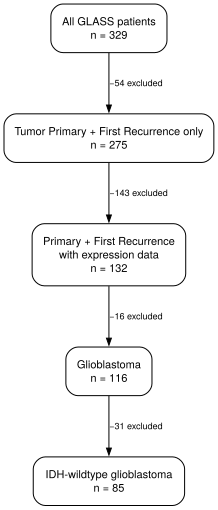

In [113]:
from graphviz import Digraph

flow = Digraph()

flow.attr(
    rankdir="TB",
    nodesep="0.5",
    ranksep="0.7"
)

flow.attr(
    "node",
    shape="box",
    style="rounded",
    fontname="Helvetica Neue",
    fontsize="11",
    margin="0.15"
)

flow.attr(
    "edge",
    fontname="Helvetica Neue",
    fontsize="9",
    arrowsize="0.7"
)

flow.node("A", f"All GLASS patients\nn = {len(n_all)}")
flow.node("B", f"Tumor Primary + First Recurrence only\nn = {len(n_tp_r1)}")
flow.node("C", f"Primary + First Recurrence\nwith expression data\nn = {len(n_tp_r1_expr)}")
flow.node("D", f"Glioblastoma\nn = {len(n_gbm)}")
flow.node("E", f"IDH-wildtype glioblastoma\nn = {len(n_idhwt_gbm)}")

# Arrows + number excluded at each step
flow.edge("A", "B",
    label=f"−{len(n_all - n_tp_r1)} excluded")

flow.edge("B", "C",
    label=f"−{len(n_tp_r1 - n_tp_r1_expr)} excluded")

flow.edge("C", "D",
    label=f"−{len(n_tp_r1_expr - n_gbm)} excluded")

flow.edge( "D", "E",
    label=f"−{len(n_gbm - n_idhwt_gbm)} excluded")


flow

In [114]:
flow.attr(dpi="300")

flow.render(
    "../figures/glass_patient_selection",
    format="png",
    cleanup=True
)

'../figures/glass_patient_selection.png'

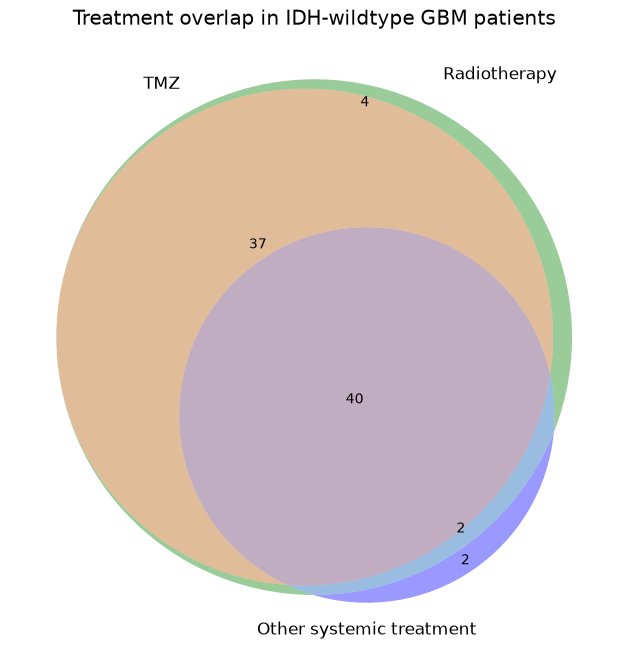

In [115]:
# noinspection PyTypeChecker
plt.figure(figsize=(8, 8))

venn3(
    (tmz, radiotherapy, other_systemic),
    set_labels=(
        "TMZ",
        "Radiotherapy",
        "Other systemic treatment"
    )
)

plt.title("Treatment overlap in IDH-wildtype GBM patients")
plt.savefig(
    "../figures/treatment_overlap_venn.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()